In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

Text(0, 0.5, 'y value')

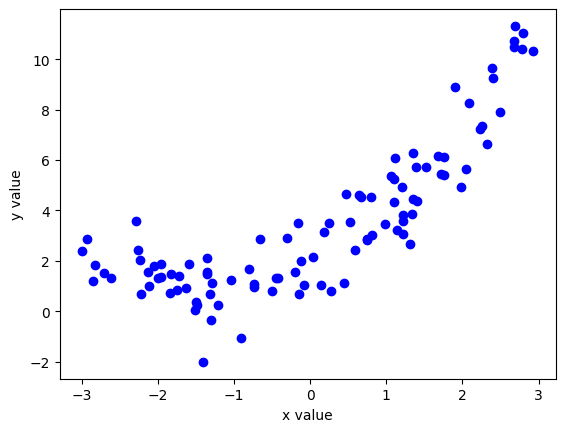

In [5]:

x = 6 * np.random.rand(100, 1) - 3
y = 0.5 * x**2 + 1.5 * x + 2 + np.random.randn(100, 1)

# quadratic equation used: y = 0.5x^2 + 1.5x + 2 + outliers

plt.scatter(x, y, color='b')

plt.xlabel("x value")
plt.ylabel("y value")


In [6]:
# train test split

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)


In [8]:
# Linear Regression

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [9]:
y_pred = model.predict(x_test)

In [10]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print(score)

0.6904680135827869


Text(0, 0.5, 'y label')

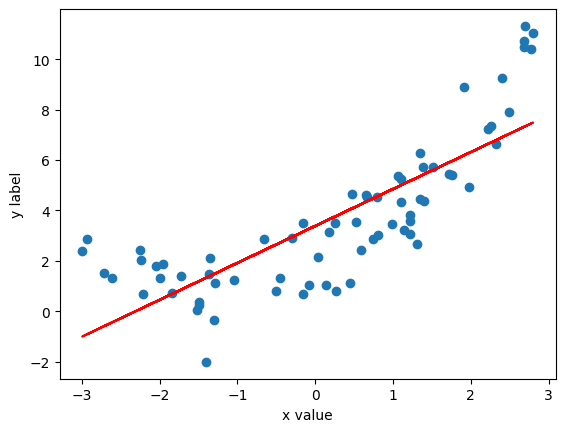

In [12]:
# visualizing the model

plt.plot(x_train, model.predict(x_train), color='r')

plt.scatter(x_train, y_train)

plt.xlabel("x value")
plt.ylabel("y label")

In [13]:
# applying polynomial transformation

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=True)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [14]:
x_test_poly

array([[ 1.        , -2.82476685,  7.97930777],
       [ 1.        , -0.73425304,  0.53912753],
       [ 1.        , -0.90808073,  0.82461061],
       [ 1.        , -0.80680332,  0.6509316 ],
       [ 1.        , -0.20493611,  0.04199881],
       [ 1.        , -0.11473956,  0.01316517],
       [ 1.        ,  2.0839322 ,  4.34277343],
       [ 1.        , -1.31729714,  1.73527175],
       [ 1.        , -1.6286737 ,  2.65257802],
       [ 1.        ,  1.33491268,  1.78199185],
       [ 1.        ,  2.39423116,  5.73234283],
       [ 1.        , -2.11526604,  4.47435041],
       [ 1.        ,  1.76330229,  3.10923498],
       [ 1.        ,  0.75273199,  0.56660546],
       [ 1.        , -1.75600649,  3.0835588 ],
       [ 1.        , -1.58931986,  2.52593762],
       [ 1.        ,  2.04179722,  4.16893588],
       [ 1.        ,  2.92835939,  8.57528873],
       [ 1.        , -2.85495821,  8.15078636],
       [ 1.        , -2.29053318,  5.24654223],
       [ 1.        , -0.74307517,  0.552

In [15]:
x_train_poly

array([[ 1.00000000e+00,  4.46405866e-01,  1.99278197e-01],
       [ 1.00000000e+00,  2.67899507e+00,  7.17701458e+00],
       [ 1.00000000e+00,  2.80109454e+00,  7.84613064e+00],
       [ 1.00000000e+00, -1.49597213e+00,  2.23793263e+00],
       [ 1.00000000e+00,  2.25735320e+00,  5.09564346e+00],
       [ 1.00000000e+00,  7.44588968e-01,  5.54412732e-01],
       [ 1.00000000e+00, -3.03522783e-01,  9.21260800e-02],
       [ 1.00000000e+00,  1.10424556e+00,  1.21935825e+00],
       [ 1.00000000e+00, -2.00082820e+00,  4.00331349e+00],
       [ 1.00000000e+00,  1.38538002e+00,  1.91927780e+00],
       [ 1.00000000e+00,  5.94704231e-01,  3.53673123e-01],
       [ 1.00000000e+00,  2.50483621e-01,  6.27420444e-02],
       [ 1.00000000e+00, -2.25699995e+00,  5.09404877e+00],
       [ 1.00000000e+00,  1.21266713e+00,  1.47056156e+00],
       [ 1.00000000e+00,  2.68297738e+00,  7.19836761e+00],
       [ 1.00000000e+00,  1.40446226e+00,  1.97251425e+00],
       [ 1.00000000e+00,  2.77804013e+00

In [16]:

model = LinearRegression()

model.fit(x_train_poly, y_train)

y_pred = model.predict(x_test_poly)

score = r2_score(y_test, y_pred)

print(score)


0.9071086012116094


In [17]:
model.coef_

array([[0.        , 1.46582788, 0.55524907]])

In [18]:
model.intercept_

array([1.89835137])

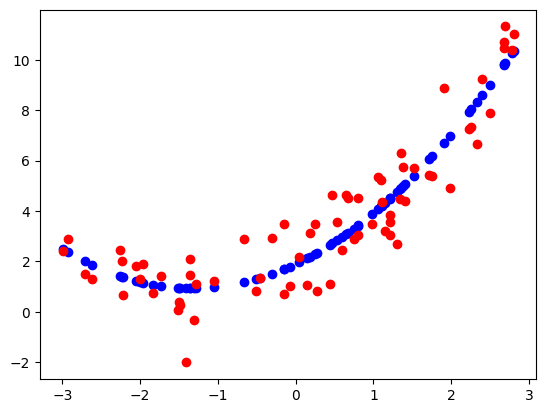

In [19]:
plt.scatter(x_train, model.predict(x_train_poly), color='b')

plt.scatter(x_train, y_train, color='r')

In [20]:
poly = PolynomialFeatures(degree=3, include_bias=True)

x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)

In [21]:
x_train_poly

array([[ 1.00000000e+00,  4.46405866e-01,  1.99278197e-01,
         8.89589560e-02],
       [ 1.00000000e+00,  2.67899507e+00,  7.17701458e+00,
         1.92271867e+01],
       [ 1.00000000e+00,  2.80109454e+00,  7.84613064e+00,
         2.19777537e+01],
       [ 1.00000000e+00, -1.49597213e+00,  2.23793263e+00,
        -3.34788485e+00],
       [ 1.00000000e+00,  2.25735320e+00,  5.09564346e+00,
         1.15026671e+01],
       [ 1.00000000e+00,  7.44588968e-01,  5.54412732e-01,
         4.12809604e-01],
       [ 1.00000000e+00, -3.03522783e-01,  9.21260800e-02,
        -2.79623642e-02],
       [ 1.00000000e+00,  1.10424556e+00,  1.21935825e+00,
         1.34647093e+00],
       [ 1.00000000e+00, -2.00082820e+00,  4.00331349e+00,
        -8.00994252e+00],
       [ 1.00000000e+00,  1.38538002e+00,  1.91927780e+00,
         2.65892912e+00],
       [ 1.00000000e+00,  5.94704231e-01,  3.53673123e-01,
         2.10330902e-01],
       [ 1.00000000e+00,  2.50483621e-01,  6.27420444e-02,
      

In [22]:
x_test_poly

array([[ 1.00000000e+00, -2.82476685e+00,  7.97930777e+00,
        -2.25396841e+01],
       [ 1.00000000e+00, -7.34253043e-01,  5.39127531e-01,
        -3.95856030e-01],
       [ 1.00000000e+00, -9.08080730e-01,  8.24610611e-01,
        -7.48813006e-01],
       [ 1.00000000e+00, -8.06803321e-01,  6.50931599e-01,
        -5.25173776e-01],
       [ 1.00000000e+00, -2.04936109e-01,  4.19988088e-02,
        -8.60707245e-03],
       [ 1.00000000e+00, -1.14739561e-01,  1.31651669e-02,
        -1.51056547e-03],
       [ 1.00000000e+00,  2.08393220e+00,  4.34277343e+00,
         9.05004540e+00],
       [ 1.00000000e+00, -1.31729714e+00,  1.73527175e+00,
        -2.28586852e+00],
       [ 1.00000000e+00, -1.62867370e+00,  2.65257802e+00,
        -4.32018406e+00],
       [ 1.00000000e+00,  1.33491268e+00,  1.78199185e+00,
         2.37880352e+00],
       [ 1.00000000e+00,  2.39423116e+00,  5.73234283e+00,
         1.37245538e+01],
       [ 1.00000000e+00, -2.11526604e+00,  4.47435041e+00,
      

In [23]:

model = LinearRegression()

model.fit(x_train_poly, y_train)

y_pred = model.predict(x_test_poly)

score = r2_score(y_test, y_pred)

print(score)

0.9065129230186078


In [24]:
# prediction on new dataset

x_new = np.linspace(-3, 3, 200).reshape(200, 1)

x_new_poly = poly.transform(x_new)

x_new_poly

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00,
        -2.70000000e+01],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00,
        -2.61940839e+01],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00,
        -2.54043665e+01],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00,
        -2.46306834e+01],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00,
        -2.38728702e+01],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00,
        -2.31307624e+01],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00,
        -2.24041955e+01],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00,
        -2.16930052e+01],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00,
        -2.09970269e+01],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00,
        -2.03160961e+01],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00,
        -1.96500486e+01],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00,
      

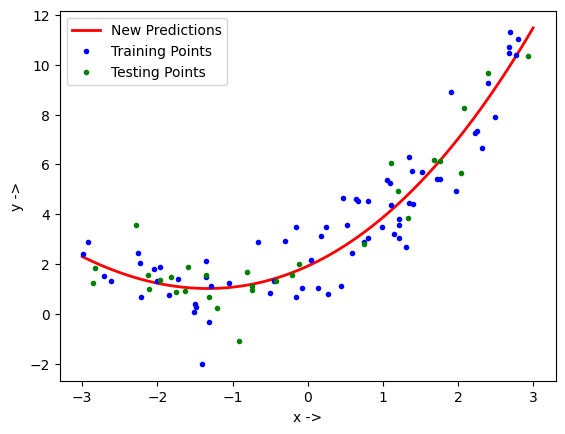

In [27]:
y_new = model.predict(x_new_poly)

plt.plot(x_new, y_new, "r-", linewidth=2, label="New Predictions")

plt.plot(x_train, y_train, "b.", label="Training Points")
plt.plot(x_test, y_test, "g.", label="Testing Points")

plt.xlabel("x ->")
plt.ylabel("y ->")

plt.legend()
plt.show()

In [28]:
# pipeline concepts

from sklearn.pipeline import Pipeline

In [33]:
def polynomial_regression(degree):

    x_new = np.linspace(-3, 3, 200).reshape(200, 1)

    poly_features = PolynomialFeatures(degree=degree, include_bias=True)

    linear = LinearRegression()
    poly = Pipeline([
        ("poly_features", poly_features),
        ("linear", linear)
    ])

    poly.fit(x_train, y_train)

    y_pred_new = poly.predict(x_new)

    plt.plot(x_new, y_pred_new, "r-", linewidth=2, label="Degree " + str(degree))

    plt.plot(x_train, y_train, "b.", label="Training Points")
    plt.plot(x_test, y_test, "g.", label="Testing Points")

    plt.xlabel("x ->")
    plt.ylabel("y ->")

    plt.legend(loc="upper left")
    plt.axis([-4, 4, 0, 10])
    plt.show()

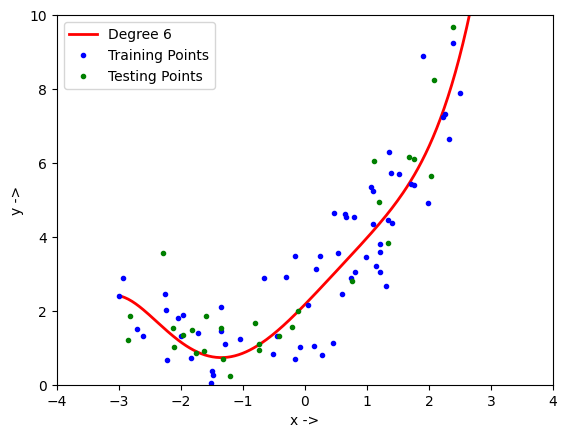

In [41]:
polynomial_regression(6)